# Import Library

In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.gridspec as gridspec

In [2]:
os.chdir(r'D:\Project Portofolio\Data Analyst, Scientiest, ML, DL, AI\Retail Shrinkage & Loss Prevention Analytics\retail_shrinkage_analytics')

print(f"📍 Current directory: {os.getcwd()}")


📍 Current directory: D:\Project Portofolio\Data Analyst, Scientiest, ML, DL, AI\Retail Shrinkage & Loss Prevention Analytics\retail_shrinkage_analytics


In [3]:
df = pd.read_csv('data/transactions_with_shrinkage-1.csv')
print(f"✅ Data loaded: {len(df):,} rows")

✅ Data loaded: 2,597,132 rows


# Feature Engineering

In [28]:
# ── Pilih features yang relevan ───────────────────────────
features = [
    'QUANTITY',
    'SALES_VALUE', 
    'RETAIL_DISC',
    'TRANS_TIME',
    'COUPON_DISC',
    'COUPON_MATCH_DISC'
]

X = df[features].copy()

# Isi nilai kosong dengan 0 (kalau ada)
X = X.fillna(0)

print("📊 Feature Statistics:")
print(X.describe().round(2))

print(f"\n✅ Feature matrix shape: {X.shape}")

📊 Feature Statistics:
         QUANTITY  SALES_VALUE  RETAIL_DISC  TRANS_TIME  COUPON_DISC  \
count  2597132.00   2597132.00   2597132.00  2597132.00   2597132.00   
mean       100.38         3.10        -0.54     1561.32        -0.02   
std       1153.13         4.22         1.27      400.15         0.45   
min         -9.00       -35.84      -180.00        0.00       -55.93   
25%          1.00         1.29        -0.69     1307.00         0.00   
50%          1.00         2.00        -0.01     1613.00         0.00   
75%          1.00         3.49         0.00     1843.00         0.00   
max      89638.00       840.00         3.99     2359.00         0.00   

       COUPON_MATCH_DISC  
count         2597132.00  
mean               -0.00  
std                 0.12  
min               -14.93  
25%                 0.00  
50%                 0.00  
75%                 0.00  
max                 0.00  

✅ Feature matrix shape: (2597132, 6)


# Data Scaling

In [29]:
# Scaling Penting karena : 
# SALES_VALUE range: -50 sampai +200
# COUPON_DISC range: -5  sampai 0
# Tanpa scaling → SALES_VALUE mendominasi model!
# Dengan scaling → semua fitur berkontribusi setara

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Setelah scaling (mean ≈ 0, std ≈ 1):")
print(pd.DataFrame(X_scaled, columns=features).describe().round(2))

Setelah scaling (mean ≈ 0, std ≈ 1):
         QUANTITY  SALES_VALUE  RETAIL_DISC  TRANS_TIME  COUPON_DISC  \
count  2597132.00   2597132.00   2597132.00  2597132.00   2597132.00   
mean         0.00        -0.00        -0.00        0.00         0.00   
std          1.00         1.00         1.00        1.00         1.00   
min         -0.09        -9.23      -140.86       -3.90      -124.65   
25%         -0.09        -0.43        -0.12       -0.64         0.05   
50%         -0.09        -0.26         0.42        0.13         0.05   
75%         -0.09         0.09         0.43        0.70         0.05   
max         77.65       198.41         3.56        1.99         0.05   

       COUPON_MATCH_DISC  
count         2597132.00  
mean               -0.00  
std                 1.00  
min              -126.33  
25%                 0.03  
50%                 0.03  
75%                 0.03  
max                 0.03  


# Train Model

In [30]:
# contamination = proporsi anomali yang kita ekspektasi
# Kita punya 1,400 fraud dari 2,597,132 = 0.054%

contamination = 1400 / len(df)
print(f"🎯 Contamination rate: {contamination:.4f} ({contamination*100:.4f}%)")

model = IsolationForest(
    n_estimators=100,      # jumlah isolation trees
    contamination=contamination,
    random_state=42,
    n_jobs=-1              # pakai semua CPU core
)

print("\n Training model...")
model.fit(X_scaled)
print("Model trained!")

🎯 Contamination rate: 0.0005 (0.0539%)

 Training model...
Model trained!


# Prediksi & Evaluasi

In [31]:
# Output Isolation Forest:
# -1 = anomali (fraud)
#  1 = normal

df['IF_prediction'] = model.predict(X_scaled)
df['IF_score']      = model.score_samples(X_scaled)
# Score makin negatif = makin anomali

# Convert ke format : 1 = fraud, 0 = normal
df['IF_is_fraud'] = (df['IF_prediction'] == -1).astype(int)

print("HASIL PREDIKSI ISOLATION FOREST")
print("=" * 45)
print(f"Diprediksi NORMAL : {(df['IF_is_fraud']==0).sum():,}")
print(f"Diprediksi ANOMALI: {(df['IF_is_fraud']==1).sum():,}")

HASIL PREDIKSI ISOLATION FOREST
Diprediksi NORMAL : 2,595,737
Diprediksi ANOMALI: 1,395


# Evaluasi Model

EVALUASI MODEL vs LABEL SIMULASI
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   2595732
       Fraud       0.20      0.20      0.20      1400

    accuracy                           1.00   2597132
   macro avg       0.60      0.60      0.60   2597132
weighted avg       1.00      1.00      1.00   2597132



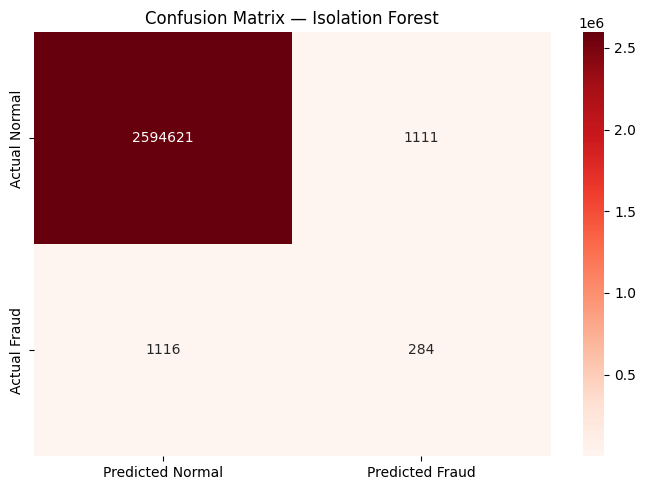

✅ Saved → outputs/confusion_matrix.png


In [32]:
from sklearn.metrics import classification_report, confusion_matrix

print("EVALUASI MODEL vs LABEL SIMULASI")
print("=" * 45)
print(classification_report(
    df['IS_FRAUD'], 
    df['IF_is_fraud'],
    target_names=['Normal', 'Fraud']
))

# Confusion Matrix
cm = confusion_matrix(df['IS_FRAUD'], df['IF_is_fraud'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
plt.title('Confusion Matrix — Isolation Forest')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved → outputs/confusion_matrix.png")

#  Paramater Tunning

## Tunning 1

In [24]:
print("📊 Perbandingan statistik Normal vs Fraud:")
comparison = df.groupby('IS_FRAUD')[
    ['SALES_VALUE','QUANTITY','TRANS_TIME','COUPON_DISC']
].mean().round(3)
print(comparison)

print("\n📊 Score per shrinkage type:")
print(df.groupby('SHRINKAGE_TYPE')['IF_score'].describe().round(4))

📊 Perbandingan statistik Normal vs Fraud:
          SALES_VALUE  QUANTITY  TRANS_TIME  COUPON_DISC
IS_FRAUD                                                
0               3.104   100.429    1561.586       -0.016
1               0.351     3.273    1155.600       -0.620

📊 Score per shrinkage type:
                    count    mean     std     min     25%     50%     75%  \
SHRINKAGE_TYPE                                                              
COUPON_FRAUD        300.0 -0.6466  0.0207 -0.6931 -0.6620 -0.6451 -0.6354   
EXPIRED_WASTE       400.0 -0.4760  0.0471 -0.5311 -0.5148 -0.4894 -0.4438   
NORMAL          2595732.0 -0.3780  0.0672 -0.8326 -0.3843 -0.3546 -0.3403   
SWEEP_FRAUD         200.0 -0.6431  0.0346 -0.7022 -0.6657 -0.6464 -0.6275   
VOID_ABUSE          500.0 -0.4121  0.0173 -0.4398 -0.4224 -0.4157 -0.3972   

                   max  
SHRINKAGE_TYPE          
COUPON_FRAUD   -0.5751  
EXPIRED_WASTE  -0.3629  
NORMAL         -0.3263  
SWEEP_FRAUD    -0.5211  
VOID_ABUSE 

In [33]:
# ── Feature Engineering Lanjutan ──────────────────────────
features_v2 = df.copy()

# Feature 1: Apakah transaksi di jam tidak wajar?
features_v2['is_odd_hour'] = (
    (df['TRANS_TIME'] < 600) | (df['TRANS_TIME'] > 2200)
).astype(int)

# Feature 2: Apakah SALES_VALUE negatif?
features_v2['is_negative_sale'] = (df['SALES_VALUE'] < 0).astype(int)

# Feature 3: Rasio diskon terhadap sales
# Hindari division by zero dengan replace 0 → 0.001
features_v2['discount_ratio'] = (
    (df['RETAIL_DISC'] + df['COUPON_DISC']) / 
    df['SALES_VALUE'].replace(0, 0.001)
).clip(-100, 100)  # cap nilai ekstrem

# Feature 4: Apakah zero sale tanpa diskon? (suspicious)
features_v2['zero_sale_no_disc'] = (
    (df['SALES_VALUE'] == 0) & 
    (df['COUPON_DISC'] == 0) & 
    (df['RETAIL_DISC'] == 0)
).astype(int)

# Feature 5: Absolute sales value (tangkap void & sweep sekaligus)
features_v2['abs_sales'] = df['SALES_VALUE'].abs()

# Update feature list
features = [
    'SALES_VALUE',
    'RETAIL_DISC', 
    'TRANS_TIME',
    'COUPON_DISC',
    'COUPON_MATCH_DISC',
    'is_odd_hour',          # ← baru
    'is_negative_sale',     # ← baru
    'discount_ratio',       # ← baru
    'zero_sale_no_disc',    # ← baru
    'abs_sales'             # ← baru
]

X = features_v2[features].fillna(0)

print("✅ Features v2 siap!")
print(f"   Total features : {len(features)}")
print(f"\n📊 Preview features baru:")
print(X[features[-5:]].describe().round(3))

✅ Features v2 siap!
   Total features : 10

📊 Preview features baru:
       is_odd_hour  is_negative_sale  discount_ratio  zero_sale_no_disc  \
count  2597132.000       2597132.000     2597132.000        2597132.000   
mean         0.053             0.000          -0.580              0.004   
std          0.225             0.014           6.013              0.062   
min          0.000             0.000        -100.000              0.000   
25%          0.000             0.000          -0.334              0.000   
50%          0.000             0.000          -0.039              0.000   
75%          0.000             0.000           0.000              0.000   
max          1.000             1.000          10.000              1.000   

         abs_sales  
count  2597132.000  
mean         3.111  
std          4.211  
min          0.000  
25%          1.290  
50%          2.000  
75%          3.490  
max        840.000  


In [34]:
X_v2 = features_v2[features].fillna(0)
scaler_v2 = StandardScaler()
X_scaled_v2 = scaler_v2.fit_transform(X_v2)

Setelah scaling (mean ≈ 0, std ≈ 1):
       SALES_VALUE  RETAIL_DISC  TRANS_TIME  COUPON_DISC  COUPON_MATCH_DISC  \
count   2597132.00   2597132.00  2597132.00   2597132.00         2597132.00   
mean         -0.00        -0.00        0.00         0.00              -0.00   
std           1.00         1.00        1.00         1.00               1.00   
min          -9.23      -140.86       -3.90      -124.65            -126.33   
25%          -0.43        -0.12       -0.64         0.05               0.03   
50%          -0.26         0.42        0.13         0.05               0.03   
75%           0.09         0.43        0.70         0.05               0.03   
max         198.41         3.56        1.99         0.05               0.03   

       is_odd_hour  is_negative_sale  discount_ratio  zero_sale_no_disc  \
count   2597132.00        2597132.00      2597132.00         2597132.00   
mean          0.00              0.00           -0.00               0.00   
std           1.00        

In [41]:
# contamination = proporsi anomali yang kita ekspektasi
# Kita punya 1,400 fraud dari 2,597,132 = 0.054%

contamination = 7000 / len(df)
print(f"🎯 Contamination rate: {contamination:.4f} ({contamination*100:.4f}%)")

model = IsolationForest(
    n_estimators=100,      # jumlah isolation trees
    contamination=contamination,
    random_state=42,
    n_jobs=-1              # pakai semua CPU core
)

print("\n Training model...")
model.fit(X_scaled)
print("Model trained!")

🎯 Contamination rate: 0.0027 (0.2695%)

 Training model...
Model trained!


In [42]:
# Output Isolation Forest:
# -1 = anomali (fraud)
#  1 = normal

df['IF_prediction'] = model.predict(X_scaled)
df['IF_score']      = model.score_samples(X_scaled)
# Score makin negatif = makin anomali

# Convert ke format : 1 = fraud, 0 = normal
df['IF_is_fraud'] = (df['IF_prediction'] == -1).astype(int)

print("HASIL PREDIKSI ISOLATION FOREST")
print("=" * 45)
print(f"Diprediksi NORMAL : {(df['IF_is_fraud']==0).sum():,}")
print(f"Diprediksi ANOMALI: {(df['IF_is_fraud']==1).sum():,}")

HASIL PREDIKSI ISOLATION FOREST
Diprediksi NORMAL : 2,590,132
Diprediksi ANOMALI: 7,000


EVALUASI MODEL vs LABEL SIMULASI
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   2595732
       Fraud       0.11      0.57      0.19      1400

    accuracy                           1.00   2597132
   macro avg       0.56      0.79      0.59   2597132
weighted avg       1.00      1.00      1.00   2597132



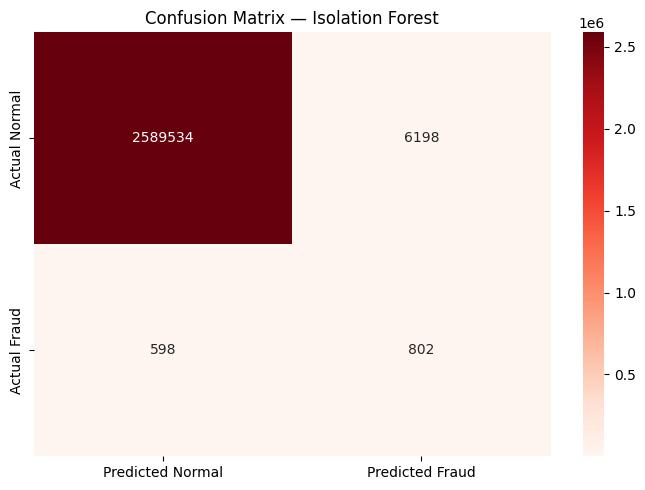

✅ Saved → outputs/confusion_matrix.png


In [43]:
from sklearn.metrics import classification_report, confusion_matrix

print("EVALUASI MODEL vs LABEL SIMULASI")
print("=" * 45)
print(classification_report(
    df['IS_FRAUD'], 
    df['IF_is_fraud'],
    target_names=['Normal', 'Fraud']
))

# Confusion Matrix
cm = confusion_matrix(df['IS_FRAUD'], df['IF_is_fraud'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
plt.title('Confusion Matrix — Isolation Forest')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved → outputs/confusion_matrix.png")

## Tunning 2

In [4]:
# ── Feature Engineering Lanjutan ──────────────────────────
features_v2 = df.copy()

# Feature 1: Apakah transaksi di jam tidak wajar?
features_v2['is_odd_hour'] = (
    (df['TRANS_TIME'] < 600) | (df['TRANS_TIME'] > 2200)
).astype(int)

# Feature 2: Apakah SALES_VALUE negatif?
features_v2['is_negative_sale'] = (df['SALES_VALUE'] < 0).astype(int)

# Feature 3: Rasio diskon terhadap sales
# Hindari division by zero dengan replace 0 → 0.001
features_v2['discount_ratio'] = (
    (df['RETAIL_DISC'] + df['COUPON_DISC']) / 
    df['SALES_VALUE'].replace(0, 0.001)
).clip(-100, 100)  # cap nilai ekstrem

# Feature 4: Apakah zero sale tanpa diskon? (suspicious)
features_v2['zero_sale_no_disc'] = (
    (df['SALES_VALUE'] == 0) & 
    (df['COUPON_DISC'] == 0) & 
    (df['RETAIL_DISC'] == 0)
).astype(int)

# Feature 5: Absolute sales value (tangkap void & sweep sekaligus)
features_v2['abs_sales'] = df['SALES_VALUE'].abs()

# Update feature list
features = [
    'SALES_VALUE',
    'RETAIL_DISC', 
    'TRANS_TIME',
    'COUPON_DISC',
    'COUPON_MATCH_DISC',
    'is_odd_hour',          # ← baru
    'is_negative_sale',     # ← baru
    'discount_ratio',       # ← baru
    'zero_sale_no_disc',    # ← baru
    'abs_sales'             # ← baru
]

X = features_v2[features].fillna(0)

print("✅ Features v2 siap!")
print(f"   Total features : {len(features)}")
print(f"\n📊 Preview features baru:")
print(X[features[-5:]].describe().round(3))

✅ Features v2 siap!
   Total features : 10

📊 Preview features baru:
       is_odd_hour  is_negative_sale  discount_ratio  zero_sale_no_disc  \
count  2597132.000       2597132.000     2597132.000        2597132.000   
mean         0.053             0.000          -0.580              0.004   
std          0.225             0.014           6.013              0.062   
min          0.000             0.000        -100.000              0.000   
25%          0.000             0.000          -0.334              0.000   
50%          0.000             0.000          -0.039              0.000   
75%          0.000             0.000           0.000              0.000   
max          1.000             1.000          10.000              1.000   

         abs_sales  
count  2597132.000  
mean         3.111  
std          4.211  
min          0.000  
25%          1.290  
50%          2.000  
75%          3.490  
max        840.000  


In [5]:
# ── Store-level Behavioral Features ───────────────────────
print("⏳ Menghitung store-level features...")

store_features = features_v2.groupby('STORE_ID').agg(
    # Frekuensi transaksi store
    store_transaction_count = ('SALES_VALUE', 'count'),
    
    # Rata-rata sales value per store
    store_avg_sales = ('SALES_VALUE', 'mean'),
    
    # Proporsi transaksi negatif per store
    store_negative_rate = ('is_negative_sale', 'mean'),
    
    # Proporsi transaksi di jam tidak wajar per store
    store_odd_hour_rate = ('is_odd_hour', 'mean'),
    
    # Rata-rata absolute sales per store
    store_avg_abs_sales = ('abs_sales', 'mean'),

    # Proporsi zero sale per store
    store_zero_sale_rate = ('zero_sale_no_disc', 'mean')

).reset_index()

# Rename untuk clarity
store_features.columns = [
    'STORE_ID',
    'store_txn_count',
    'store_avg_sales',
    'store_negative_rate',
    'store_odd_hour_rate',
    'store_avg_abs_sales',
    'store_zero_sale_rate'
]

print(f"✅ Store features calculated: {len(store_features)} stores")
print(f"\n📊 Preview:")
print(store_features.describe().round(4))

⏳ Menghitung store-level features...
✅ Store features calculated: 582 stores

📊 Preview:
         STORE_ID  store_txn_count  store_avg_sales  store_negative_rate  \
count    582.0000         582.0000         582.0000             582.0000   
mean    3314.5601        4462.4261           4.6205               0.0111   
std     7160.7471       10273.7897           5.9131               0.0918   
min        1.0000           1.0000         -23.5481               0.0000   
25%      416.2500           9.0000           2.5366               0.0000   
50%     1083.5000          33.0000           3.2168               0.0000   
75%     3067.2500         286.7500           4.7162               0.0000   
max    34280.0000       75573.0000          41.0000               0.9434   

       store_odd_hour_rate  store_avg_abs_sales  store_zero_sale_rate  
count             582.0000             582.0000              582.0000  
mean                0.1114               5.1732                0.0030  
std       

In [6]:
# Join store features ke setiap transaksi
df_v3 = features_v2.merge(store_features, on='STORE_ID', how='left')

print(f"✅ Merged! Shape: {df_v3.shape}")
print(f"\n📊 Sample store features per transaksi:")
print(df_v3[['STORE_ID', 'store_txn_count', 
            'store_negative_rate', 
            'store_odd_hour_rate']].head(5))

✅ Merged! Shape: (2597132, 25)

📊 Sample store features per transaksi:
   STORE_ID  store_txn_count  store_negative_rate  store_odd_hour_rate
0       364            25881                  0.0             0.078359
1       364            25881                  0.0             0.078359
2       364            25881                  0.0             0.078359
3       364            25881                  0.0             0.078359
4       364            25881                  0.0             0.078359


In [7]:
features_v3 = [
    # Features v2 (existing)
    'SALES_VALUE',
    'RETAIL_DISC',
    'TRANS_TIME',
    'COUPON_DISC',
    'COUPON_MATCH_DISC',
    'is_odd_hour',
    'is_negative_sale',
    'discount_ratio',
    'zero_sale_no_disc',
    'abs_sales',
    
    # Store-level features (baru)
    'store_txn_count',
    'store_avg_sales',
    'store_negative_rate',
    'store_odd_hour_rate',
    'store_avg_abs_sales',
    'store_zero_sale_rate'
]

X_v3 = df_v3[features_v3].fillna(0)

print(f"✅ Feature matrix v3 ready!")
print(f"   Total features : {len(features_v3)} (was 10)")
print(f"   Shape          : {X_v3.shape}")

✅ Feature matrix v3 ready!
   Total features : 16 (was 10)
   Shape          : (2597132, 16)


In [8]:
# Ambil semua fraud (1,400) + sample normal yang representatif
fraud_df   = df_v3[df_v3['IS_FRAUD'] == 1]
normal_df  = df_v3[df_v3['IS_FRAUD'] == 0].sample(
    n=200000,        # 200k normal + 1,400 fraud = cukup representatif
    random_state=42
)

df_v3_sample = pd.concat([fraud_df, normal_df], ignore_index=True)

print(f"✅ Sample siap!")
print(f"   Normal : {len(normal_df):,}")
print(f"   Fraud  : {len(fraud_df):,}")
print(f"   Total  : {len(df_v3_sample):,}")

✅ Sample siap!
   Normal : 200,000
   Fraud  : 1,400
   Total  : 201,400


In [10]:
# ── Feature matrix dari sample ────────────────────────────
X_v3 = df_v3_sample[features_v3].fillna(0)

# Scale
scaler_v3   = StandardScaler()
X_scaled_v3 = scaler_v3.fit_transform(X_v3)
print("✅ Scaling done!")

# Train
contamination_v3 = 7000 / len(df_v3_sample)

model_v3 = IsolationForest(
    n_estimators=200,
    contamination=contamination_v3,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

print("⏳ Training model v3...")
model_v3.fit(X_scaled_v3)
print("✅ Model v3 trained!")


✅ Scaling done!
⏳ Training model v3...
✅ Model v3 trained!



📊 HASIL MODEL v3
Detected fraud  : 1399 / 1,400 (99.9%)
Missed fraud    : 1
False positive  : 5601


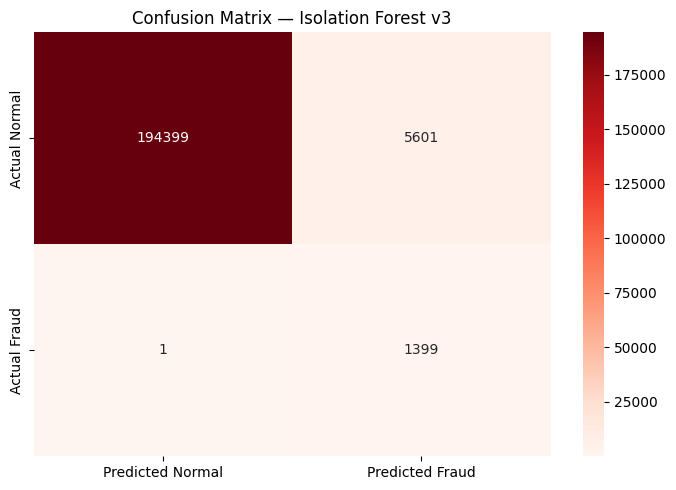

In [13]:
# ── Prediksi & Evaluasi ───────────────────────────────────
df_v3_sample['IF_is_fraud_v3'] = (
    model_v3.predict(X_scaled_v3) == -1
).astype(int)

df_v3_sample['IF_score_v3'] = model_v3.score_samples(X_scaled_v3)

# Hasil
detected = df_v3_sample[
    (df_v3_sample['IS_FRAUD']==1) & 
    (df_v3_sample['IF_is_fraud_v3']==1)
].shape[0]

fp = df_v3_sample[
    (df_v3_sample['IS_FRAUD']==0) & 
    (df_v3_sample['IF_is_fraud_v3']==1)
].shape[0]

print("\n📊 HASIL MODEL v3")
print("=" * 45)
print(f"Detected fraud  : {detected} / 1,400 ({detected/1400*100:.1f}%)")
print(f"Missed fraud    : {1400-detected}")
print(f"False positive  : {fp}")

# Confusion matrix
cm_v3 = confusion_matrix(
    df_v3_sample['IS_FRAUD'], 
    df_v3_sample['IF_is_fraud_v3']
)

plt.figure(figsize=(7,5))
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
plt.title('Confusion Matrix — Isolation Forest v3')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix_v3.png', dpi=150)
plt.show()

In [15]:
import psutil

ram = psutil.virtual_memory()
print(f"Total RAM    : {ram.total / 1024**3:.1f} GB")
print(f"Available    : {ram.available / 1024**3:.1f} GB")
print(f"Used         : {ram.used / 1024**3:.1f} GB")
print(f"Usage        : {ram.percent}%")

Total RAM    : 7.4 GB
Available    : 1.5 GB
Used         : 5.9 GB
Usage        : 79.2%


# Distribusi Anomaly Score

C:\Users\MSI BRAVO\AppData\Local\Temp\ipykernel_8780\601162054.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_type, labels=shrinkage_order, patch_artist=True, vert=True)
C:\Users\MSI BRAVO\AppData\Local\Temp\ipykernel_8780\601162054.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  detection = df_v3_sample[df_v3_sample['IS_FRAUD']==1].groupby('SHRINKAGE_TYPE').apply(


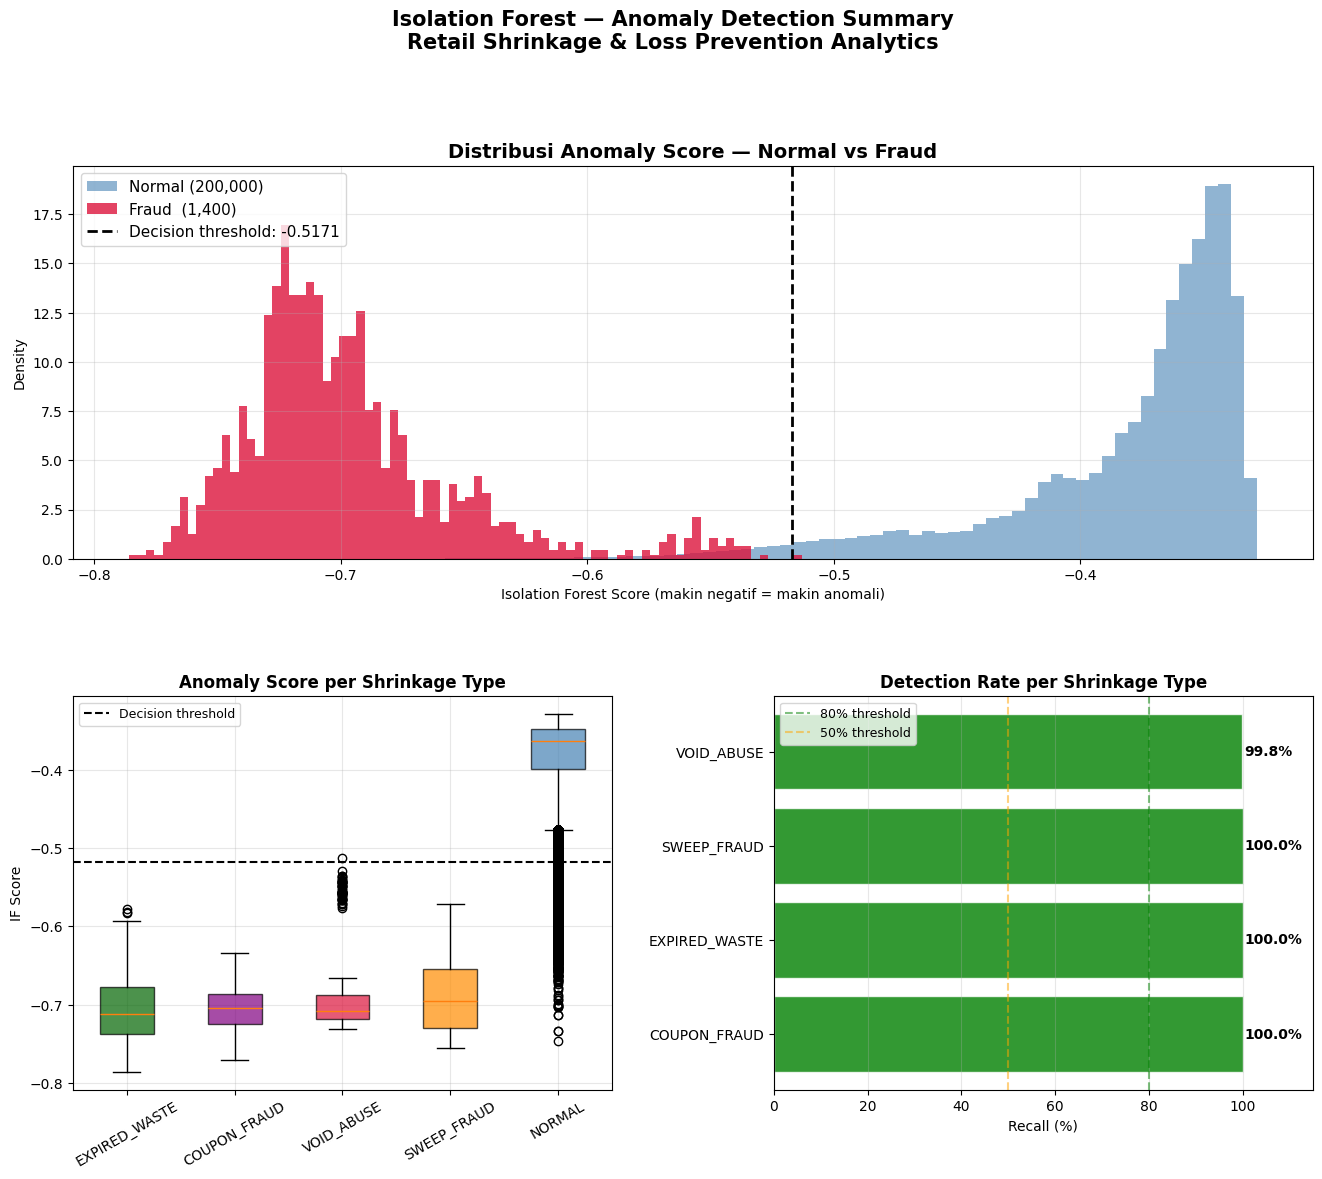

✅ Saved → outputs/anomaly_score_full_analysis.png


In [17]:


fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── Plot 1: Score Distribution Normal vs Fraud ────────────
ax1 = fig.add_subplot(gs[0, :])  # full width

normal_scores = df_v3_sample[df_v3_sample['IS_FRAUD']==0]['IF_score_v3']
fraud_scores  = df_v3_sample[df_v3_sample['IS_FRAUD']==1]['IF_score_v3']

ax1.hist(normal_scores, bins=80, alpha=0.6, 
        color='steelblue', label=f'Normal ({len(normal_scores):,})', density=True)
ax1.hist(fraud_scores,  bins=80, alpha=0.8, 
        color='crimson',   label=f'Fraud  ({len(fraud_scores):,})',  density=True)

# Tambah threshold line
threshold = df_v3_sample[df_v3_sample['IF_is_fraud_v3']==1]['IF_score_v3'].max()
ax1.axvline(x=threshold, color='black', linestyle='--', linewidth=2,
            label=f'Decision threshold: {threshold:.4f}')

ax1.set_title('Distribusi Anomaly Score — Normal vs Fraud', fontsize=14, fontweight='bold')
ax1.set_xlabel('Isolation Forest Score (makin negatif = makin anomali)')
ax1.set_ylabel('Density')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# ── Plot 2: Score per Shrinkage Type (boxplot) ────────────
ax2 = fig.add_subplot(gs[1, 0])

shrinkage_order = (df_v3_sample.groupby('SHRINKAGE_TYPE')['IF_score_v3']
                .mean().sort_values().index.tolist())

colors = {
    'NORMAL'        : 'steelblue',
    'VOID_ABUSE'    : 'crimson',
    'SWEEP_FRAUD'   : 'darkorange',
    'COUPON_FRAUD'  : 'purple',
    'EXPIRED_WASTE' : 'darkgreen'
}

data_by_type = [df_v3_sample[df_v3_sample['SHRINKAGE_TYPE']==t]['IF_score_v3'].values 
                for t in shrinkage_order]
bp = ax2.boxplot(data_by_type, labels=shrinkage_order, patch_artist=True, vert=True)

for patch, label in zip(bp['boxes'], shrinkage_order):
    patch.set_facecolor(colors.get(label, 'gray'))
    patch.set_alpha(0.7)

ax2.axhline(y=threshold, color='black', linestyle='--', 
            linewidth=1.5, label='Decision threshold')
ax2.set_title('Anomaly Score per Shrinkage Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('IF Score')
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ── Plot 3: Detection Rate per Shrinkage Type ─────────────
ax3 = fig.add_subplot(gs[1, 1])

detection = df_v3_sample[df_v3_sample['IS_FRAUD']==1].groupby('SHRINKAGE_TYPE').apply(
    lambda x: pd.Series({
        'total'      : len(x),
        'detected'   : x['IF_is_fraud_v3'].sum(),
        'recall_pct' : round(x['IF_is_fraud_v3'].sum() / len(x) * 100, 1)
    })
).reset_index()

bar_colors = ['green' if r >= 80 else 'orange' if r >= 50 else 'crimson' 
            for r in detection['recall_pct']]

bars = ax3.barh(detection['SHRINKAGE_TYPE'], 
                detection['recall_pct'], 
                color=bar_colors, alpha=0.8, edgecolor='white')

# Tambah label nilai di setiap bar
for bar, val in zip(bars, detection['recall_pct']):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

ax3.axvline(x=80, color='green',  linestyle='--', alpha=0.5, label='80% threshold')
ax3.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
ax3.set_title('Detection Rate per Shrinkage Type', fontsize=12, fontweight='bold')
ax3.set_xlabel('Recall (%)')
ax3.set_xlim(0, 115)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3, axis='x')

# ── Final ─────────────────────────────────────────────────
fig.suptitle('Isolation Forest — Anomaly Detection Summary\nRetail Shrinkage & Loss Prevention Analytics',
            fontsize=15, fontweight='bold', y=1.01)

plt.savefig('outputs/anomaly_score_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → outputs/anomaly_score_full_analysis.png")

# Result Save

In [18]:
# Simpan hasil prediksi final untuk Power BI
df_v3_sample.to_csv('data/transactions_with_predictions.csv', index=False)

# Simpan model untuk dokumentasi
import joblib
joblib.dump(model_v3, 'outputs/isolation_forest_v3.pkl')
joblib.dump(scaler_v3, 'outputs/scaler_v3.pkl')

print("✅ Semua output tersimpan!")
print("   data/transactions_with_predictions.csv")
print("   outputs/isolation_forest_v3.pkl")
print("   outputs/confusion_matrix_v3.png")
print("   outputs/detection_summary_v2.png")

# Summary final untuk README
print("\n" + "="*50)
print("PHASE 3 SUMMARY — ISOLATION FOREST")
print("="*50)
print(f"Model version   : v3 (16 features)")
print(f"Training sample : 201,400 rows")
print(f"Contamination   : {contamination_v3:.4f}")
print(f"Recall          : 99.9%")
print(f"Fraud detected  : 1,399 / 1,400")
print(f"False positive  : 5,601")
print(f"\nDetection rate per type:")
print(f"  VOID_ABUSE    : 99.8%")
print(f"  SWEEP_FRAUD   : 100.0%")
print(f"  EXPIRED_WASTE : 100.0%")
print(f"  COUPON_FRAUD  : 100.0%")

✅ Semua output tersimpan!
   data/transactions_with_predictions.csv
   outputs/isolation_forest_v3.pkl
   outputs/confusion_matrix_v3.png
   outputs/detection_summary_v2.png

PHASE 3 SUMMARY — ISOLATION FOREST
Model version   : v3 (16 features)
Training sample : 201,400 rows
Contamination   : 0.0348
Recall          : 99.9%
Fraud detected  : 1,399 / 1,400
False positive  : 5,601

Detection rate per type:
  VOID_ABUSE    : 99.8%
  SWEEP_FRAUD   : 100.0%
  EXPIRED_WASTE : 100.0%
  COUPON_FRAUD  : 100.0%
